# Predicting Power Generation for Likely Scenarios

This notebook builds a model to predict power generation and applies it to the weather scenarios defined in the previous analysis.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import os

# Set plot style
plt.style.use('ggplot')
sns.set_palette('viridis')

## 1. Model Training

We'll train a model to predict `DC_POWER` based on `IRRADIATION`, `AMBIENT_TEMPERATURE`, and `MODULE_TEMPERATURE`.

In [14]:



# Helper to load and merge (reused from previous analysis)
def load_data():
    p1_gen = pd.read_csv('../../data/Plant_1_Generation_Data (2).csv')
    p1_weather = pd.read_csv('../../data/Plant_1_Weather_Sensor_Data (2).csv')
    p1_gen['DATE_TIME'] = pd.to_datetime(p1_gen['DATE_TIME'], dayfirst=True)
    p1_weather['DATE_TIME'] = pd.to_datetime(p1_weather['DATE_TIME'])
    
    p1_gen_agg = p1_gen.groupby('DATE_TIME')[['DC_POWER']].mean().reset_index()
    merged = pd.merge(p1_gen_agg, p1_weather, on='DATE_TIME')
    return merged

data = load_data()

# Features and Target
X = data[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]
y = data['DC_POWER']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

print(f"Model R^2 Score: {model.score(X, y):.4f}")

Model R^2 Score: 0.9992


## 2. Loading Weather Scenarios

We load the profiles generated in the `weather_scenario_analysis.ipynb` notebook.

In [15]:
if not os.path.exists('weather_scenarios.csv'):
    print("Error: Run weather_scenario_analysis.ipynb first!")
else:
    scenarios = pd.read_csv('weather_scenarios.csv')
    scenarios.head()

## 3. Predicting Generation for Scenarios

Now we use the model to forecast what the power output would be under each scenario.

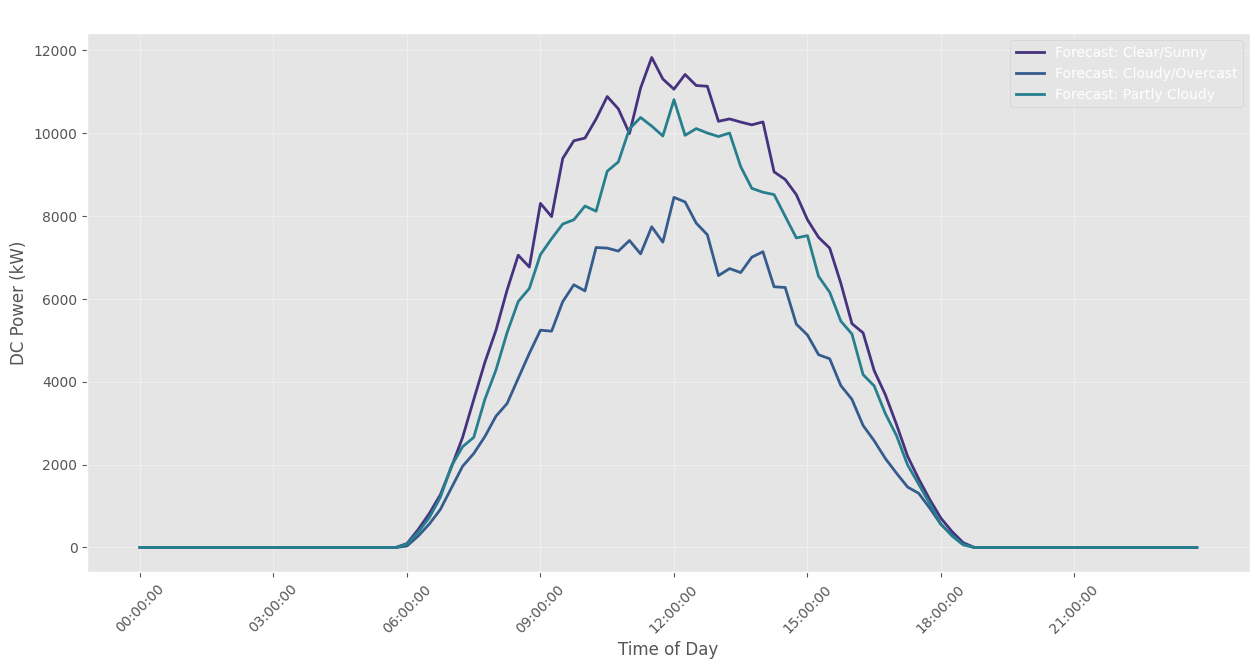

Predicted Daily Yield (kWh) per Scenario:
SCENARIO
Clear/Sunny        85240.793771
Cloudy/Overcast    56411.340216
Partly Cloudy      75378.369872
Name: PREDICTED_DC_POWER, dtype: float64


In [16]:
if 'scenarios' in locals():
    # Prepare features from scenario profiles
    X_scenarios = scenarios[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]
    
    # Predict
    scenarios['PREDICTED_DC_POWER'] = model.predict(X_scenarios)
    
    # Plotting the forecast
    plt.figure(figsize=(15, 7))
    for scenario in scenarios['SCENARIO'].unique():
        subset = scenarios[scenarios['SCENARIO'] == scenario]
        plt.plot(subset['TIME'], subset['PREDICTED_DC_POWER'], label=f"Forecast: {scenario}", linewidth=2)

    plt.xticks(scenarios['TIME'].unique()[::12], rotation=45)
    plt.title('Predicted Power Generation for Next few days (Likely Scenarios)')
    plt.ylabel('DC Power (kW)')
    plt.xlabel('Time of Day')
    plt.legend()
    plt.show()
    
    # Calculate expected daily totals
    # Note: Values are 15-min intervals, so we divide by 4 to get kWh
    daily_totals = scenarios.groupby('SCENARIO')['PREDICTED_DC_POWER'].sum() / 4
    print("Predicted Daily Yield (kWh) per Scenario:")
    print(daily_totals)

## 4. Conclusion

By combining historical weather clustering with a regression model, we can provide a range of likely power generation forecasts. Instead of a single number, this approach gives plant operators a "best-case", "average-case", and "worst-case" view based on weather forecasts.